# Лабораторная работа №4

In [1]:
from pathlib import Path
import itertools
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import Markdown, display
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("Datasets")
KUIPER_PATH = DATA_DIR / "kuiper.xls"
CIGARETTES_PATH = DATA_DIR / "cigarettes.dat.txt"

ALPHA = 0.05

## Загрузка данных

In [2]:
kuiper = pd.read_excel(KUIPER_PATH, sheet_name="Cars Lab Data")
kuiper = kuiper[["Price", "Mileage", "Cylinder", "Liter", "Cruise"]].copy()

cigarettes = pd.read_csv(
    CIGARETTES_PATH,
    sep=r"\s+",
    header=None,
    names=["brand", "tar", "nicotine", "weight", "carbon_monoxide"],
)

print("Kuiper:", kuiper.shape)
display(kuiper.head())
display(kuiper.describe())

print("Cigarettes:", cigarettes.shape)
display(cigarettes.head())
display(cigarettes.describe())

Kuiper: (804, 5)


,Price,Mileage,Cylinder,Liter,Cruise
0,17314.1031,8221,6,3.1,1
1,17542.0361,9135,6,3.1,1
2,16218.8479,13196,6,3.1,1
3,16336.9131,16342,6,3.1,1
4,16339.1703,19832,6,3.1,1


,Price,Mileage,Cylinder,Liter,Cruise
count,804.0000,804.0000,804.0000,804.0000,804.0000
mean,21343.1438,19831.9341,5.2687,3.0373,0.7525
std,9884.8528,8196.3197,1.3875,1.1056,0.4318
min,8638.9309,266.0000,4.0000,1.6000,0.0000
25%,14273.0739,14623.5000,4.0000,2.2000,1.0000
50%,18024.9950,20913.5000,6.0000,2.8000,1.0000
75%,26717.3166,25213.0000,6.0000,3.8000,1.0000
max,70755.4667,50387.0000,8.0000,6.0000,1.0000


Cigarettes: (25, 5)


,brand,tar,nicotine,weight,carbon_monoxide
0,Alpine,14.1,0.86,0.9853,13.6
1,Benson&Hedges,16.0,1.06,1.0938,16.6
2,BullDurham,29.8,2.03,1.1650,23.5
3,CamelLights,8.0,0.67,0.9280,10.2
4,Carlton,4.1,0.40,0.9462,5.4


,tar,nicotine,weight,carbon_monoxide
count,25.0000,25.0000,25.0000,25.0000
mean,12.2160,0.8764,0.9703,12.5280
std,5.6658,0.3541,0.0877,4.7397
min,1.0000,0.1300,0.7851,1.5000
25%,8.6000,0.6900,0.9225,10.0000
50%,12.8000,0.9000,0.9573,13.0000
75%,15.1000,1.0200,1.0070,15.4000
max,29.8000,2.0300,1.1650,23.5000


## Функции анализа

In [3]:
# Строит модель по заданной зависимой переменной и списку факторов
def fit_model(df, target, predictors):
    formula = f"{target} ~ {' + '.join(predictors)}"
    return smf.ols(formula=formula, data=df).fit()


# Возвращает текстовый вывод о значимости
def p_conclusion(p_value, alpha=ALPHA):
    return "значимо" if p_value < alpha else "не значимо"


# Формирует уравнение регрессии
def regression_equation(model, target):
    parts = [f"{model.params['Intercept']:.4f}"]
    for name, value in model.params.items():
        if name == "Intercept":
            continue
        sign = "+" if value >= 0 else "-"
        parts.append(f"{sign} {abs(value):.4f}*{name}")
    return f"{target} = " + " ".join(parts)


# Собирает основные метрики качества модели
def model_metrics(model):
    return pd.DataFrame(
        {
            "R2": [model.rsquared],
            "Adj_R2": [model.rsquared_adj],
            "AIC": [model.aic],
            "BIC": [model.bic],
            "F": [model.fvalue],
            "F_pvalue": [model.f_pvalue],
            "n": [int(model.nobs)],
        }
    )


# Собирает таблицу коэффициентов: оценка, стандартная ошибка, t-статистика и p-value
def coefficients_table(model):
    table = pd.DataFrame(
        {
            "coef": model.params,
            "std_err": model.bse,
            "t": model.tvalues,
            "p_value": model.pvalues,
        }
    )
    table["significant_5pct"] = table["p_value"] < ALPHA
    return table


# Возвращает 95% доверительные интервалы для коэффициентов модели
def confidence_intervals(model):
    ci = model.conf_int(alpha=ALPHA)
    ci.columns = ["ci_low_95", "ci_high_95"]
    return ci


# Выполняет корреляционный анализ и строит тепловую карту корреляций
def correlation_analysis(df, target, predictors, title):
    display(Markdown(f"### Корреляционный анализ: {title}"))
    cols = [target] + predictors
    corr = df[cols].corr(numeric_only=True)
    display(corr.round(4))

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
    ax.set_title(f"Матрица корреляций: {title}")
    plt.tight_layout()
    plt.show()

    target_corr = corr[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
    print("Корреляция факторов с зависимой переменной:")
    display(target_corr.to_frame("corr_with_target"))
    return corr


# Строит scatterplot для каждого фактора и простую линию регрессии
def plot_scatter_regression(df, target, predictors, title):
    display(Markdown(f"### Scatterplot и линии простой регрессии: {title}"))
    n_cols = 2
    n_rows = int(np.ceil(len(predictors) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, predictor in zip(axes, predictors):
        sns.regplot(data=df, x=predictor, y=target, ax=ax, scatter_kws={"alpha": 0.65})
        ax.set_title(f"{target} от {predictor}")

    for ax in axes[len(predictors):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Выводит основную информацию по модели: метрики, уравнение, t-test, F-test и интервалы
def model_report(model, target, predictors, title):
    display(Markdown(f"### {title}"))
    display(model_metrics(model).round(4))

    print("Уравнение регрессии:")
    print(regression_equation(model, target))

    display(Markdown("#### Проверка значимости отдельных коэффициентов: t-test"))
    coef_table = coefficients_table(model)
    display(coef_table.round(6))
    for name, row in coef_table.iterrows():
        if name == "Intercept":
            continue
        print(f"{name}: p-value = {row['p_value']:.6f}, коэффициент {p_conclusion(row['p_value'])} на уровне 5%.")

    display(Markdown("#### Проверка значимости уравнения: F-test"))
    print(f"F = {model.fvalue:.4f}, p-value = {model.f_pvalue:.6g}.")
    print(
        "Вывод: уравнение регрессии в целом "
        + ("статистически значимо." if model.f_pvalue < ALPHA else "не является статистически значимым.")
    )

    display(Markdown("#### 95% доверительные интервалы коэффициентов"))
    display(confidence_intervals(model).round(6))
    return coef_table


# Находит выбросы, точки с высоким leverage и влиятельные наблюдения по Cook's distance
def influential_observations(df, target, model, id_col=None, top_n=10):
    display(Markdown("### Важные и влиятельные наблюдения"))
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    studentized = influence.resid_studentized_external

    n = int(model.nobs)
    k = len(model.params)
    cooks_threshold = 4 / n
    leverage_threshold = 2 * k / n

    result = pd.DataFrame(
        {
            "row_index": df.index,
            "actual": df[target].to_numpy(),
            "fitted": model.fittedvalues.to_numpy(),
            "residual": model.resid.to_numpy(),
            "studentized_residual": studentized,
            "leverage": leverage,
            "cooks_d": cooks_d,
        }
    )
    if id_col:
        result.insert(1, id_col, df[id_col].to_numpy())

    result["possible_outlier"] = result["studentized_residual"].abs() > 3
    result["high_leverage"] = result["leverage"] > leverage_threshold
    result["influential_by_cook"] = result["cooks_d"] > cooks_threshold
    result["needs_attention"] = (
        result["possible_outlier"] | result["high_leverage"] | result["influential_by_cook"]
    )

    print(f"Порог Cook's distance: 4/n = {cooks_threshold:.4f}")
    print(f"Порог leverage: 2*k/n = {leverage_threshold:.4f}, где k - число коэффициентов включая intercept.")
    display(result.sort_values("cooks_d", ascending=False).head(top_n).round(6))

    flagged = result[result["needs_attention"]].sort_values("cooks_d", ascending=False)
    print(f"Наблюдений, требующих внимания: {len(flagged)}")
    if len(flagged) > 0:
        display(flagged.round(6))
    else:
        print("Сильных выбросов или влиятельных наблюдений по выбранным порогам не найдено.")

    return result


# Выполняет обратный пошаговый отбор факторов по критерию AIC
def backward_aic(df, target, predictors):
    current = list(predictors)
    best_model = fit_model(df, target, current)
    steps = [
        {
            "step": 0,
            "action": "start",
            "removed": None,
            "predictors": ", ".join(current),
            "AIC": best_model.aic,
        }
    ]

    step = 1
    while len(current) > 1:
        candidates = []
        for predictor in current:
            trial_predictors = [p for p in current if p != predictor]
            trial_model = fit_model(df, target, trial_predictors)
            candidates.append((trial_model.aic, predictor, trial_predictors, trial_model))

        best_aic, removed, trial_predictors, trial_model = min(candidates, key=lambda item: item[0])
        if best_aic < best_model.aic - 1e-8:
            current = trial_predictors
            best_model = trial_model
            steps.append(
                {
                    "step": step,
                    "action": "remove",
                    "removed": removed,
                    "predictors": ", ".join(current),
                    "AIC": best_model.aic,
                }
            )
            step += 1
        else:
            break

    return best_model, current, pd.DataFrame(steps)


# Считает VIF для проверки мультиколлинеарности факторов
def vif_table(df, predictors):
    if len(predictors) == 1:
        return pd.DataFrame({"variable": predictors, "VIF": [1.0]})

    x = sm.add_constant(df[predictors], has_constant="add")
    rows = []
    for i, col in enumerate(x.columns):
        if col == "const":
            continue
        rows.append({"variable": col, "VIF": variance_inflation_factor(x.values, i)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)


# Строит основные диагностические графики регрессионной модели
def diagnostic_plots(df, target, model, title):
    display(Markdown(f"### Диагностические графики: {title}"))
    influence = model.get_influence()
    fitted = model.fittedvalues
    residuals = model.resid
    leverage = influence.hat_matrix_diag
    studentized = influence.resid_studentized_internal
    cooks_d = influence.cooks_distance[0]
    max_cook = np.nanmax(cooks_d) if np.nanmax(cooks_d) > 0 else 1
    sizes = 40 + 400 * cooks_d / max_cook

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    sns.scatterplot(x=fitted, y=df[target], ax=axes[0, 0])
    low = min(float(fitted.min()), float(df[target].min()))
    high = max(float(fitted.max()), float(df[target].max()))
    axes[0, 0].plot([low, high], [low, high], color="crimson", linewidth=2)
    axes[0, 0].set_title("Scatterplot: фактические vs предсказанные")
    axes[0, 0].set_xlabel("Предсказанные")
    axes[0, 0].set_ylabel("Фактические")

    sns.residplot(x=fitted, y=residuals, lowess=True, ax=axes[0, 1], line_kws={"color": "crimson"})
    axes[0, 1].axhline(0, color="black", linewidth=1)
    axes[0, 1].set_title("Residuals vs Fitted")
    axes[0, 1].set_xlabel("Предсказанные")
    axes[0, 1].set_ylabel("Остатки")

    sm.qqplot(studentized, line="45", ax=axes[1, 0])
    axes[1, 0].set_title("Normal Q-Q")

    axes[1, 1].scatter(leverage, studentized, s=sizes, alpha=0.65)
    axes[1, 1].axhline(0, color="black", linewidth=1)
    axes[1, 1].axhline(3, color="crimson", linestyle="--", linewidth=1)
    axes[1, 1].axhline(-3, color="crimson", linestyle="--", linewidth=1)
    axes[1, 1].set_title("Residuals vs Leverage")
    axes[1, 1].set_xlabel("Leverage")
    axes[1, 1].set_ylabel("Стандартизированные остатки")

    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


# Проверяет предпосылки модели: Breusch-Pagan, Durbin-Watson, Shapiro-Wilk и VIF
def diagnostic_tests(df, model, predictors, title):
    display(Markdown(f"### Проверки предпосылок модели: {title}"))

    bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(model.resid, model.model.exog)
    dw = durbin_watson(model.resid)
    shapiro_stat, shapiro_pvalue = stats.shapiro(model.resid)

    tests = pd.DataFrame(
        [
            {
                "test": "Breusch-Pagan heteroskedasticity",
                "statistic": bp_f,
                "p_value": bp_f_pvalue,
                "interpretation": "есть признаки гетероскедастичности" if bp_f_pvalue < ALPHA else "гетероскедастичность не обнаружена",
            },
            {
                "test": "Durbin-Watson autocorrelation",
                "statistic": dw,
                "p_value": np.nan,
                "interpretation": "есть признаки положительной автокорреляции" if dw < 1.5 else ("есть признаки отрицательной автокорреляции" if dw > 2.5 else "выраженная автокорреляция не обнаружена"),
            },
            {
                "test": "Shapiro-Wilk normality",
                "statistic": shapiro_stat,
                "p_value": shapiro_pvalue,
                "interpretation": "остатки отличаются от нормального распределения" if shapiro_pvalue < ALPHA else "нет оснований отвергать нормальность остатков",
            },
        ]
    )
    display(tests.round(6))
    print("Для Durbin-Watson p-value не считается: значение около 2 обычно говорит об отсутствии выраженной автокорреляции.")

    vif = vif_table(df, predictors)
    display(Markdown("#### Проверка мультиколлинеарности: VIF"))
    display(vif.round(4))
    max_vif = float(vif["VIF"].max())
    if max_vif >= 10:
        print("Вывод по VIF: есть сильная мультиколлинеарность.")
    elif max_vif >= 5:
        print("Вывод по VIF: есть умеренная мультиколлинеарность, модель стоит интерпретировать осторожно.")
    else:
        print("Вывод по VIF: сильной мультиколлинеарности не обнаружено.")

    return {"tests": tests, "durbin_watson": dw, "vif": vif}


# Применяет Box-Cox трансформацию зависимой переменной и повторяет анализ модели
def boxcox_analysis(df, target, predictors, title):
    display(Markdown(f"### Box-Cox трансформация зависимой переменной: {title}"))
    if (df[target] <= 0).any():
        print("Box-Cox нельзя применить напрямую, потому что зависимая переменная содержит неположительные значения.")
        return None

    transformed, lambda_value = stats.boxcox(df[target].to_numpy())
    transformed_target = f"{target}_boxcox"
    transformed_df = df.copy()
    transformed_df[transformed_target] = transformed

    print(f"Оптимальная lambda Box-Cox = {lambda_value:.4f}")

    model = fit_model(transformed_df, transformed_target, predictors)
    model_report(model, transformed_target, predictors, f"Модель после Box-Cox: {title}")
    diagnostic_plots(transformed_df, transformed_target, model, f"Box-Cox модель: {title}")
    diagnostics = diagnostic_tests(transformed_df, model, predictors, f"Box-Cox модель: {title}")
    return {
        "model": model,
        "lambda": lambda_value,
        "diagnostics": diagnostics,
        "target": transformed_target,
    }


# Запускает полный сценарий анализа для одного датасета
def run_full_analysis(df, target, predictors, title, id_col=None):
    display(Markdown(f"## {title}"))

    needed_cols = ([id_col] if id_col else []) + [target] + predictors
    data = df[needed_cols].copy().dropna()

    print(f"Размер данных после удаления пропусков: {data.shape[0]} строк, {data.shape[1]} столбцов.")
    display(data.head())
    display(data[[target] + predictors].describe().round(4))

    corr = correlation_analysis(data, target, predictors, title)
    plot_scatter_regression(data, target, predictors, title)

    base_model = fit_model(data, target, predictors)
    model_report(base_model, target, predictors, f"Базовая модель: {title}")
    base_influence = influential_observations(data, target, base_model, id_col=id_col)

    display(Markdown("### Улучшение модели через backward StepAIC"))
    selected_model, selected_predictors, step_table = backward_aic(data, target, predictors)
    display(step_table.round(4))
    if selected_predictors == list(predictors):
        print("StepAIC не нашел удаления факторов, которое уменьшает AIC. Итоговая модель совпадает с базовой.")
    else:
        removed = [p for p in predictors if p not in selected_predictors]
        print(f"StepAIC исключил факторы: {', '.join(removed)}.")
        model_report(selected_model, target, selected_predictors, f"Модель после StepAIC: {title}")

    final_model = selected_model
    final_predictors = selected_predictors
    final_title = f"Итоговая модель: {title}"
    display(Markdown(f"### Диагностика итоговой модели: {title}"))
    diagnostic_plots(data, target, final_model, final_title)
    final_diagnostics = diagnostic_tests(data, final_model, final_predictors, final_title)
    final_influence = influential_observations(data, target, final_model, id_col=id_col)

    boxcox = boxcox_analysis(data, target, final_predictors, title)

    display(Markdown(f"### Краткий вывод: {title}"))
    print(f"Итоговые факторы: {', '.join(final_predictors)}")
    print(f"Adj. R2 итоговой модели: {final_model.rsquared_adj:.4f}")
    print(f"p-value F-test: {final_model.f_pvalue:.6g}")
    print(
        "Модель в целом значима на 5% уровне."
        if final_model.f_pvalue < ALPHA
        else "Модель в целом незначима на 5% уровне."
    )

    return {
        "data": data,
        "target": target,
        "initial_predictors": list(predictors),
        "base_model": base_model,
        "base_influence": base_influence,
        "selected_predictors": final_predictors,
        "selected_model": final_model,
        "final_diagnostics": final_diagnostics,
        "final_influence": final_influence,
        "boxcox": boxcox,
        "correlation": corr,
    }

## Анализ датасета `Kuiper`

## Kuiper: цена автомобилей

Размер данных после удаления пропусков: 804 строк, 5 столбцов.


,Price,Mileage,Cylinder,Liter,Cruise
0,17314.1031,8221,6,3.1,1
1,17542.0361,9135,6,3.1,1
2,16218.8479,13196,6,3.1,1
3,16336.9131,16342,6,3.1,1
4,16339.1703,19832,6,3.1,1


,Price,Mileage,Cylinder,Liter,Cruise
count,804.0000,804.0000,804.0000,804.0000,804.0000
mean,21343.1438,19831.9341,5.2687,3.0373,0.7525
std,9884.8528,8196.3197,1.3875,1.1056,0.4318
min,8638.9309,266.0000,4.0000,1.6000,0.0000
25%,14273.0739,14623.5000,4.0000,2.2000,1.0000
50%,18024.9950,20913.5000,6.0000,2.8000,1.0000
75%,26717.3166,25213.0000,6.0000,3.8000,1.0000
max,70755.4667,50387.0000,8.0000,6.0000,1.0000


### Корреляционный анализ: Kuiper: цена автомобилей

,Price,Mileage,Cylinder,Liter,Cruise
Price,1.0000,-0.1431,0.5691,0.5581,0.4309
Mileage,-0.1431,1.0000,-0.0295,-0.0186,0.0250
Cylinder,0.5691,-0.0295,1.0000,0.9579,0.3543
Liter,0.5581,-0.0186,0.9579,1.0000,0.3775
Cruise,0.4309,0.0250,0.3543,0.3775,1.0000


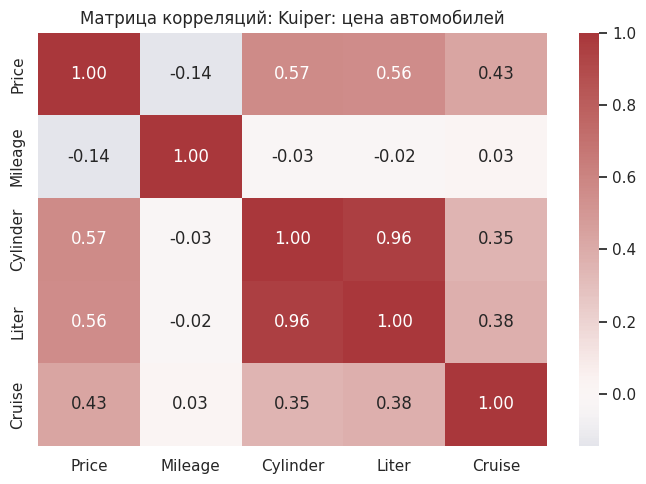

Корреляция факторов с зависимой переменной:


,corr_with_target
Cylinder,0.5691
Liter,0.5581
Cruise,0.4309
Mileage,-0.1431


### Scatterplot и линии простой регрессии: Kuiper: цена автомобилей

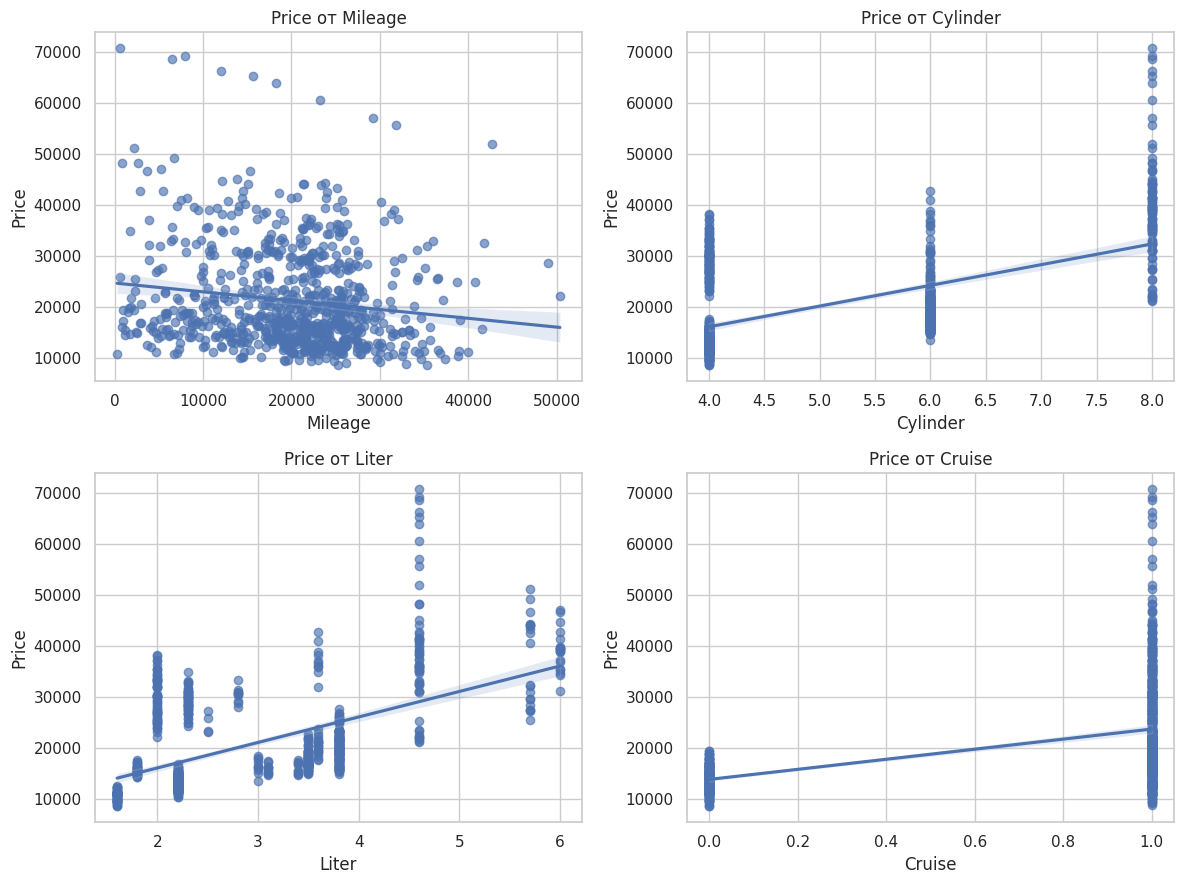

### Базовая модель: Kuiper: цена автомобилей

,R2,Adj_R2,AIC,BIC,F,F_pvalue,n
0,0.4026,0.3996,16668.0826,16691.5306,134.6068,0.0,804


Уравнение регрессии:
Price = 2799.8569 - 0.1644*Mileage + 3007.8027*Cylinder + 455.7311*Liter + 6076.0488*Cruise


#### Проверка значимости отдельных коэффициентов: t-test

,coef,std_err,t,p_value,significant_5pct
Intercept,2799.8569,1543.2648,1.8142,7.0015e-02,False
Mileage,-0.1644,0.0330,-4.9771,1.0000e-06,True
Cylinder,3007.8027,679.2712,4.4280,1.1000e-05,True
Liter,455.7311,860.5960,0.5296,5.9657e-01,False
Cruise,6076.0488,676.5703,8.9807,0.0000e+00,True


...

F = 179.5437, p-value = 5.35343e-89.
Вывод: уравнение регрессии в целом статистически значимо.


#### 95% доверительные интервалы коэффициентов

,ci_low_95,ci_high_95
Intercept,-151.5035,4816.5480
Mileage,-0.2287,-0.0991
Cylinder,2941.0851,3759.2154
Cruise,4812.3466,7440.7646


### Диагностика итоговой модели: Kuiper: цена автомобилей

### Диагностические графики: Итоговая модель: Kuiper: цена автомобилей

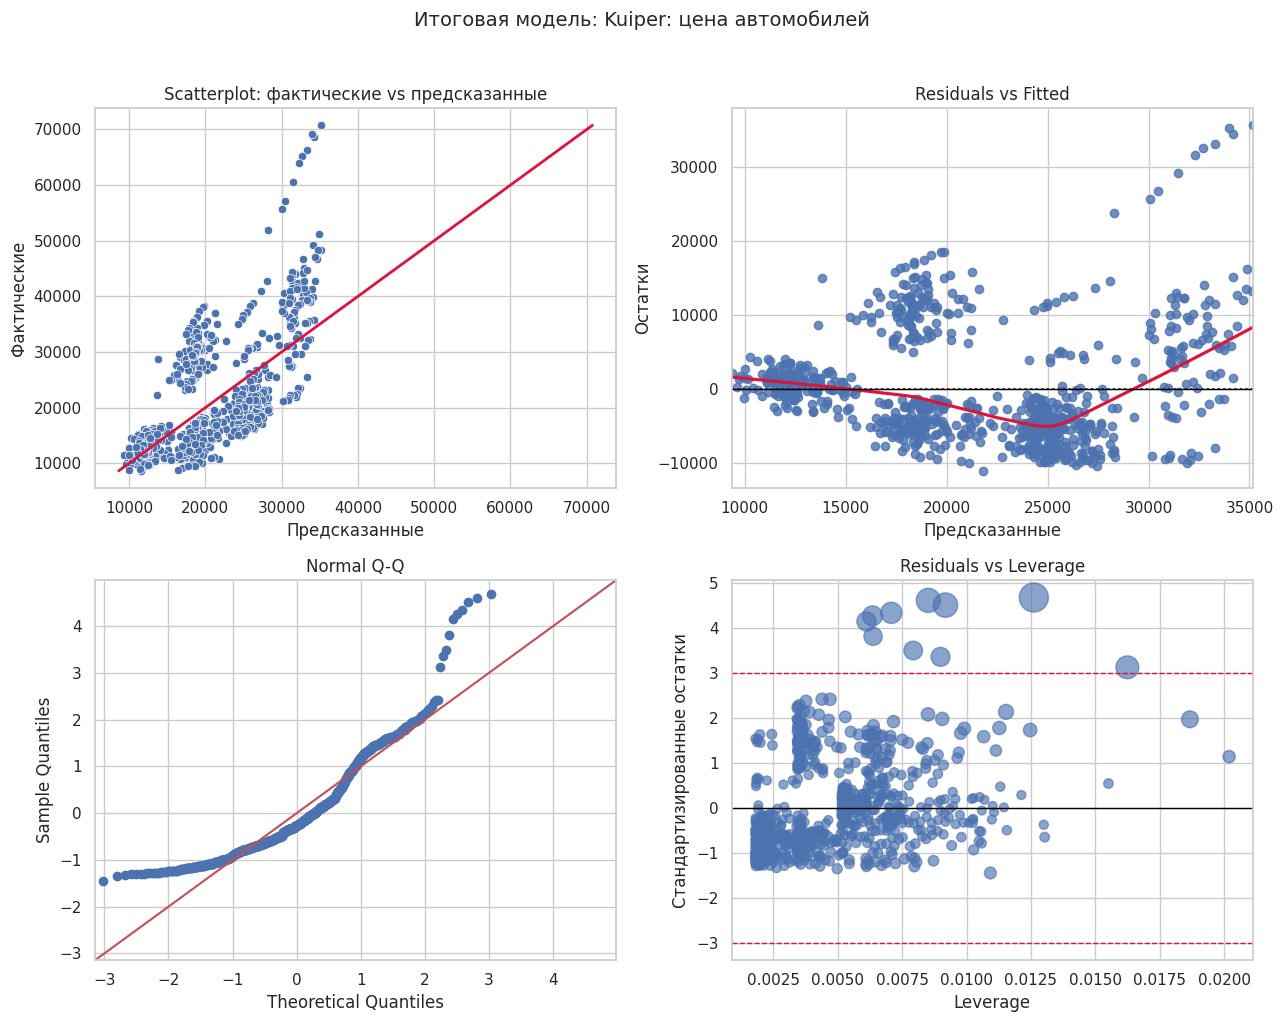

### Проверки предпосылок модели: Итоговая модель: Kuiper: цена автомобилей

,test,statistic,p_value,interpretation
0,Breusch-Pagan heteroskedasticity,25.5740,0.0,есть признаки гетероскедастичности
1,Durbin-Watson autocorrelation,0.2201,NaN,есть признаки положительной автокорреляции
2,Shapiro-Wilk normality,0.8971,0.0,остатки отличаются от нормального распределения


Для Durbin-Watson p-value не считается: значение около 2 обычно говорит об отсутствии выраженной автокорреляции.


#### Проверка мультиколлинеарности: VIF

,variable,VIF
1,Cylinder,1.1455
2,Cruise,1.1452
0,Mileage,1.0023


...

#### Проверка значимости уравнения: F-test

F = 234.8250, p-value = 2.96321e-109.
Вывод: уравнение регрессии в целом статистически значимо.


#### 95% доверительные интервалы коэффициентов

,ci_low_95,ci_high_95
Intercept,1.7167,1.7174
Mileage,-0.0000,-0.0000
Cylinder,0.0004,0.0005
Cruise,0.0009,0.0012


### Диагностические графики: Box-Cox модель: Kuiper: цена автомобилей

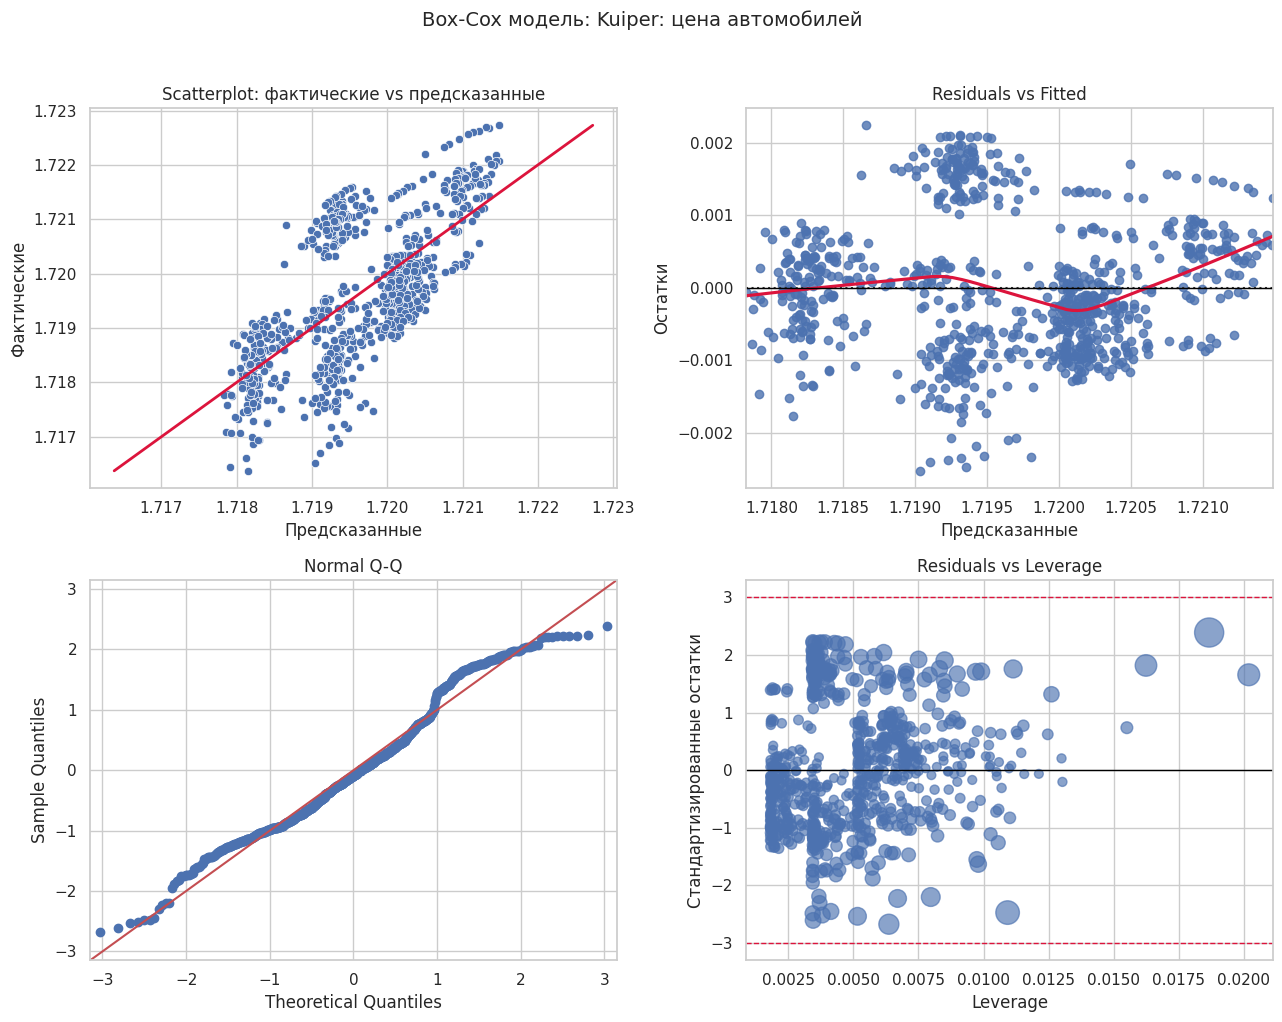

### Проверки предпосылок модели: Box-Cox модель: Kuiper: цена автомобилей

,test,statistic,p_value,interpretation
0,Breusch-Pagan heteroskedasticity,146.3664,0.0,есть признаки гетероскедастичности
1,Durbin-Watson autocorrelation,0.3299,NaN,есть признаки положительной автокорреляции
2,Shapiro-Wilk normality,0.9764,0.0,остатки отличаются от нормального распределения


Для Durbin-Watson p-value не считается: значение около 2 обычно говорит об отсутствии выраженной автокорреляции.


#### Проверка мультиколлинеарности: VIF

,variable,VIF
1,Cylinder,1.1455
2,Cruise,1.1452
0,Mileage,1.0023


Вывод по VIF: сильной мультиколлинеарности не обнаружено.


### Краткий вывод: Kuiper: цена автомобилей

Итоговые факторы: Mileage, Cylinder, Cruise
Adj. R2 итоговой модели: 0.4001
p-value F-test: 5.35343e-89
Модель в целом значима на 5% уровне.


In [4]:
results = {}
results["Kuiper"] = run_full_analysis(
    df=kuiper,
    target="Price",
    predictors=["Mileage", "Cylinder", "Liter", "Cruise"],
    title="Kuiper: цена автомобилей",
)

## Анализ датасета `cigarettes.dat.txt`

## Cigarettes: содержание carbon monoxide

Размер данных после удаления пропусков: 25 строк, 5 столбцов.


,brand,carbon_monoxide,tar,nicotine,weight
0,Alpine,13.6,14.1,0.86,0.9853
1,Benson&Hedges,16.6,16.0,1.06,1.0938
2,BullDurham,23.5,29.8,2.03,1.1650
3,CamelLights,10.2,8.0,0.67,0.9280
4,Carlton,5.4,4.1,0.40,0.9462


,carbon_monoxide,tar,nicotine,weight
count,25.0000,25.0000,25.0000,25.0000
mean,12.5280,12.2160,0.8764,0.9703
std,4.7397,5.6658,0.3541,0.0877
min,1.5000,1.0000,0.1300,0.7851
25%,10.0000,8.6000,0.6900,0.9225
50%,13.0000,12.8000,0.9000,0.9573
75%,15.4000,15.1000,1.0200,1.0070
max,23.5000,29.8000,2.0300,1.1650


### Корреляционный анализ: Cigarettes: содержание carbon monoxide

,carbon_monoxide,tar,nicotine,weight
carbon_monoxide,1.0000,0.9575,0.9259,0.4640
tar,0.9575,1.0000,0.9766,0.4908
nicotine,0.9259,0.9766,1.0000,0.5002
weight,0.4640,0.4908,0.5002,1.0000


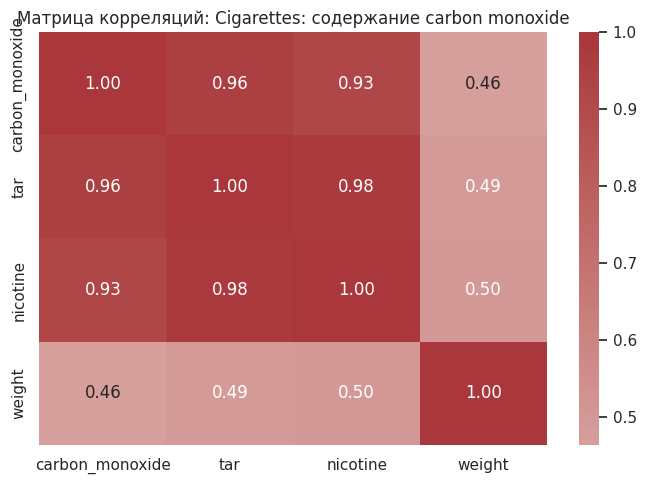

Корреляция факторов с зависимой переменной:


,corr_with_target
tar,0.9575
nicotine,0.9259
weight,0.4640


### Scatterplot и линии простой регрессии: Cigarettes: содержание carbon monoxide

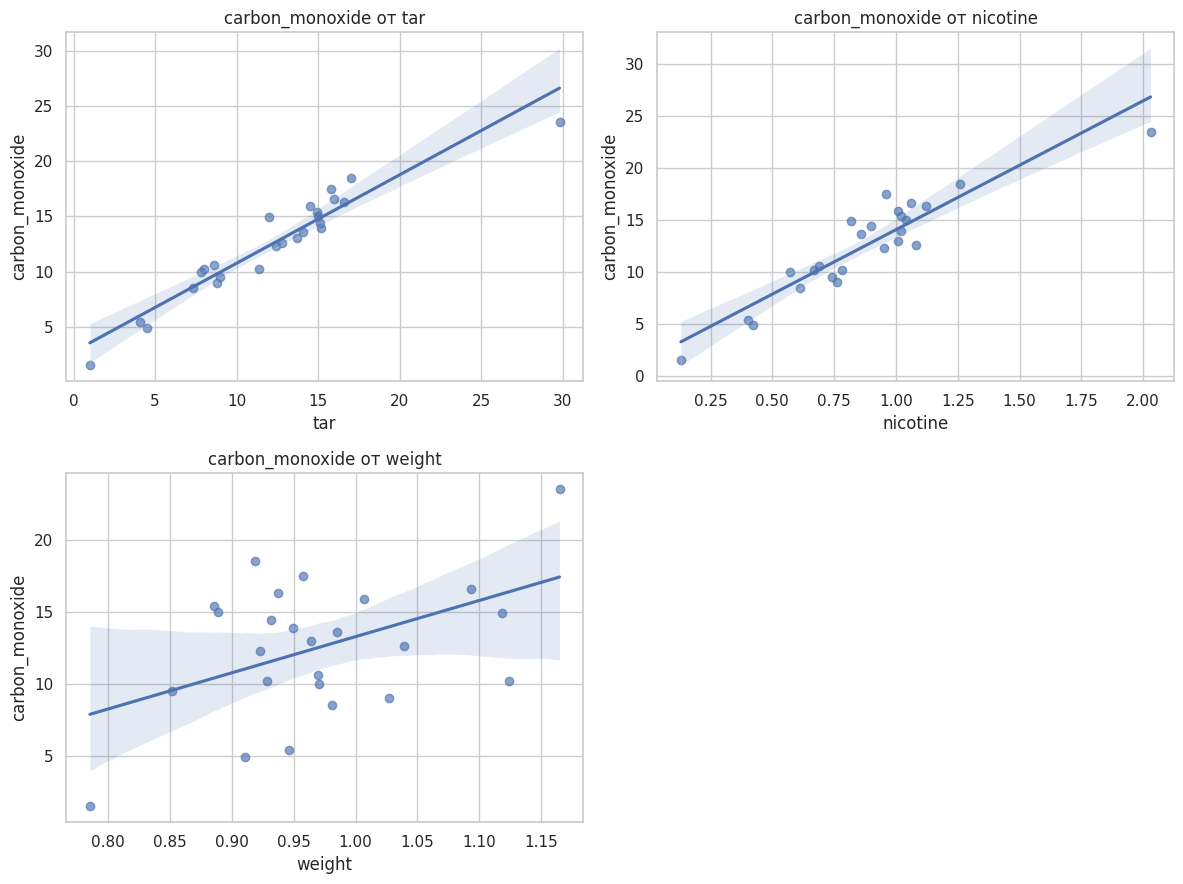

### Базовая модель: Cigarettes: содержание carbon monoxide

,R2,Adj_R2,AIC,BIC,F,F_pvalue,n
0,0.9186,0.907,93.0187,97.8942,78.9838,0.0,25


Уравнение регрессии:
carbon_monoxide = 3.2022 + 0.9626*tar - 2.6317*nicotine - 0.1305*weight


#### Проверка значимости отдельных коэффициентов: t-test

,coef,std_err,t,p_value,significant_5pct
Intercept,3.2022,3.4618,0.9250,0.3655,False
tar,0.9626,0.2422,3.9736,0.0007,True
nicotine,-2.6317,3.9006,-0.6747,0.5072,False
weight,-0.1305,3.8853,-0.0336,0.9735,False


...

F = 253.3697, p-value = 6.55224e-14.
Вывод: уравнение регрессии в целом статистически значимо.


#### 95% доверительные интервалы коэффициентов

,ci_low_95,ci_high_95
Intercept,1.3465,4.1400
tar,0.6969,0.9051


### Диагностика итоговой модели: Cigarettes: содержание carbon monoxide

### Диагностические графики: Итоговая модель: Cigarettes: содержание carbon monoxide

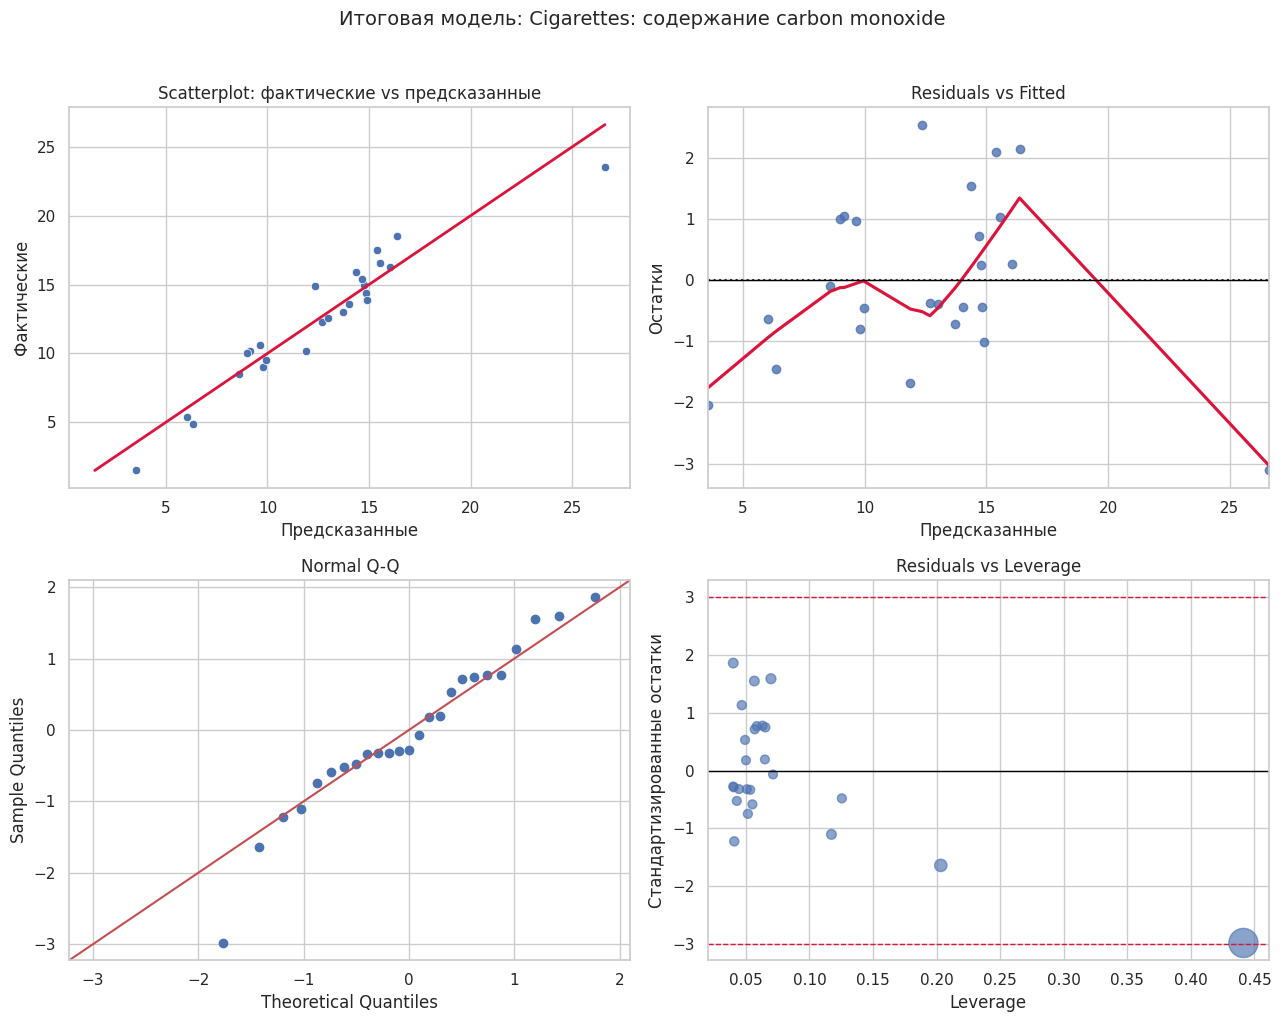

### Проверки предпосылок модели: Итоговая модель: Cigarettes: содержание carbon monoxide

,test,statistic,p_value,interpretation
0,Breusch-Pagan heteroskedasticity,5.1256,0.0333,есть признаки гетероскедастичности
1,Durbin-Watson autocorrelation,2.8927,NaN,есть признаки отрицательной автокорреляции
2,Shapiro-Wilk normality,0.9785,0.8547,нет оснований отвергать нормальность остатков


Для Durbin-Watson p-value не считается: значение около 2 обычно говорит об отсутствии выраженной автокорреляции.


#### Проверка мультиколлинеарности: VIF

,variable,VIF
0,tar,1.0


...

#### Проверка значимости уравнения: F-test

F = 276.3495, p-value = 2.60675e-14.
Вывод: уравнение регрессии в целом статистически значимо.


#### 95% доверительные интервалы коэффициентов

,ci_low_95,ci_high_95
Intercept,-0.2393,3.0953
tar,0.8743,1.1228


### Диагностические графики: Box-Cox модель: Cigarettes: содержание carbon monoxide

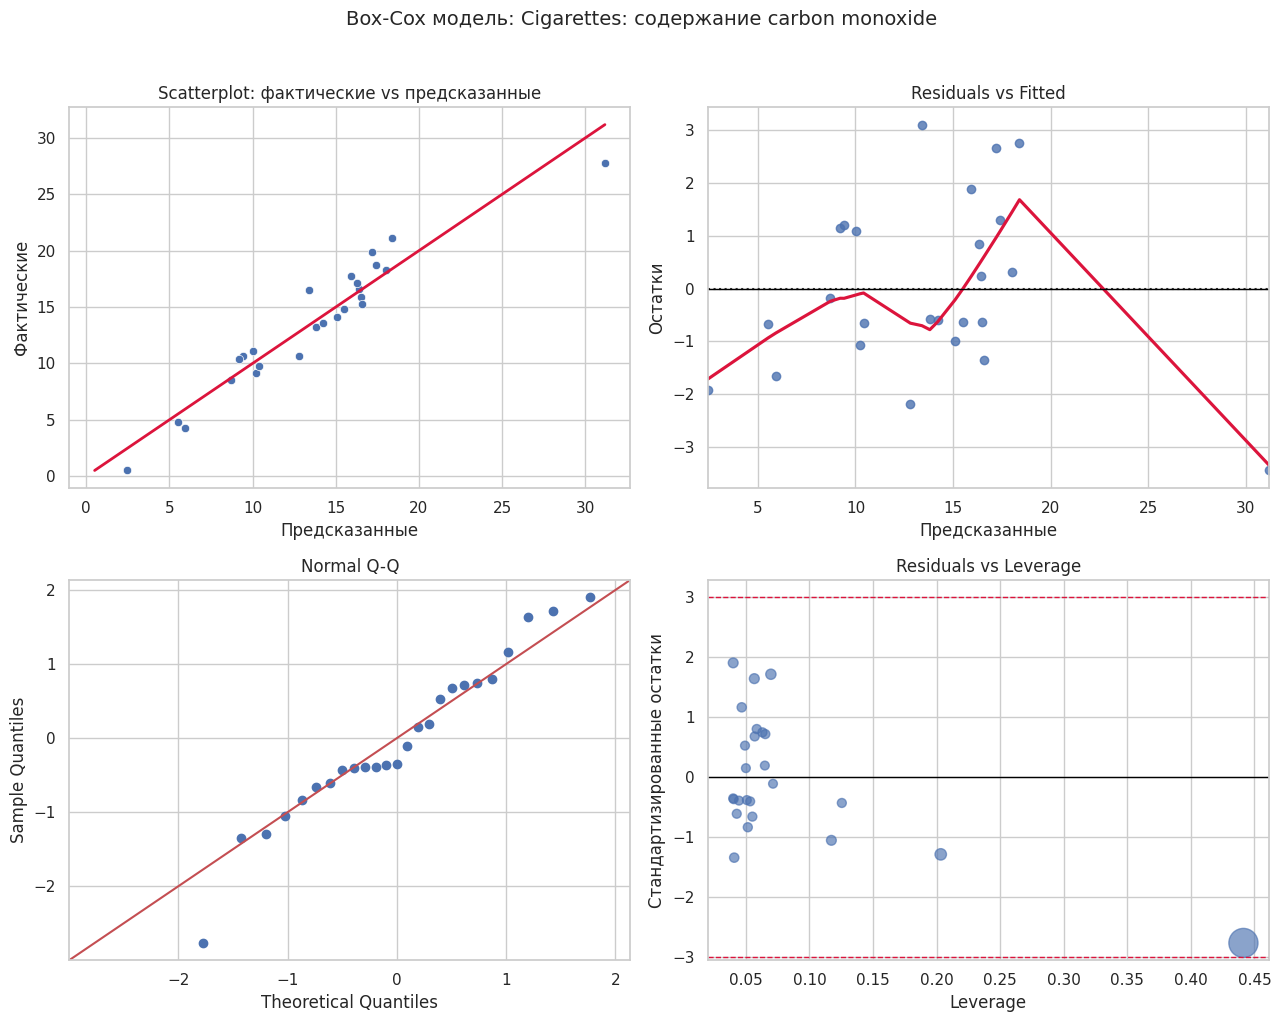

### Проверки предпосылок модели: Box-Cox модель: Cigarettes: содержание carbon monoxide

,test,statistic,p_value,interpretation
0,Breusch-Pagan heteroskedasticity,6.2263,0.0202,есть признаки гетероскедастичности
1,Durbin-Watson autocorrelation,2.8762,NaN,есть признаки отрицательной автокорреляции
2,Shapiro-Wilk normality,0.9722,0.7000,нет оснований отвергать нормальность остатков


Для Durbin-Watson p-value не считается: значение около 2 обычно говорит об отсутствии выраженной автокорреляции.


#### Проверка мультиколлинеарности: VIF

,variable,VIF
0,tar,1.0


Вывод по VIF: сильной мультиколлинеарности не обнаружено.


### Краткий вывод: Cigarettes: содержание carbon monoxide

Итоговые факторы: tar
Adj. R2 итоговой модели: 0.9132
p-value F-test: 6.55224e-14
Модель в целом значима на 5% уровне.


In [5]:
results["Cigarettes"] = run_full_analysis(
    df=cigarettes,
    target="carbon_monoxide",
    predictors=["tar", "nicotine", "weight"],
    title="Cigarettes: содержание carbon monoxide",
    id_col="brand",
)